In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
filename = "data/all_vis_all_cams_with_yield.xlsx"
features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method']
output_variable = 'GYLD_kg_m3'

hour_of_the_day = 13 #can be 10

In [ ]:
df = pd.read_excel(filename)

if hour_of_the_day == 13:
    df_hour = df[(df['hour'] > 11) & (df['hour'] < 14)].copy()
else:
    df_hour = df[df['hour'] < 12].copy()

# Filter yield greater than 0
df_hour = df_hour[(df_hour[output_variable] > 0)]

In [ ]:
# Checking duplicates
duplicates = df_hour.groupby(['plot_id', 'date']).size().reset_index(name='count')
duplicates = duplicates[duplicates['count'] > 1]

print(duplicates) # 0 results, Good!

In [ ]:
df_hour13 = df_hour[["plot_id", "date"] + features + [output_variable]].copy()

In [ ]:
print(df_hour13.head())
print(df_hour13.describe())

In [ ]:
df_hour13['date'] = pd.to_datetime(df_hour13['date'])
df_hour13 = df_hour13.sort_values([  'plot_id', 'date',])

In [ ]:
print(df_hour13.head(48))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
yields = []

for plot_id, group in df_hour13.groupby('plot_id'):
    yield_value = group[output_variable].iloc[0]  # yield per plot
    yields.append(yield_value)


yields = np.array(yields)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

min_y = yields.min()
max_y = yields.max()
bins = np.arange(np.floor(min_y), np.ceil(max_y) + 0.1, 0.1)

plt.figure(figsize=(8, 5))
sns.histplot(yields, bins=bins, kde=False, color='skyblue', edgecolor='black')
plt.title(f'Histogram of {output_variable} (Buckets of 0.1')
plt.xlabel(f'{output_variable}')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
df_hour13[output_variable].hist(bins=20)
print(df[output_variable].describe())
print("Skewness:", df[output_variable].skew())


In [ ]:


def plot_available_data(dataset):
    df_avail = dataset.copy()

    for feature in features:
        presence = df_avail.pivot_table(
            index='plot_id',
            columns='date',
            values=feature,
            aggfunc='size',
            fill_value=0
        )
        presence = presence.map(lambda x: 1 if x > 0 else 0)

        plt.figure(figsize=(15, 8))
        sns.heatmap(presence, cmap="Greens", cbar=False)
        plt.title(f"Data Availability by Plot and Date ({feature})")
        plt.xlabel("Date")
        plt.ylabel("Plot ID")
        plt.show()

plot_available_data(df_hour13)

In [ ]:
df_hour13 = df_hour13[(df_hour13['date'] >= '2024-05-01') & (df_hour13['date'] <= '2024-06-30')]
plot_available_data(df_hour13)


In [ ]:
# Count how many rows per plot_id and date
duplicates = df_hour13.groupby(['plot_id', 'date']).size().reset_index(name='count')

# Filter only those with more than 1 NDVI value
duplicates = duplicates[duplicates['count'] > 1]

print(duplicates) # 0 results, Good!

In [ ]:
# Plot the NDVI over the time
plot_to_check = "8_w"  # pick first plot for example

def plot_VI_over_time_per_plot(plot_no, feature_name, vi_name, non_interpolated_dataset, with_interpolation=False, interpolation_method="", interpolated_dataset=None):

    plot_data = non_interpolated_dataset[non_interpolated_dataset['plot_id'] == plot_no]

    plt.figure(figsize=(12,6))

    if with_interpolation:
        if interpolated_dataset is None:
            raise ValueError("Interpolated dataset is missing in the arguments")
        plot_data_interpolated = interpolated_dataset[interpolated_dataset['plot_id'] == plot_no]
        plt.plot(plot_data_interpolated['date'], plot_data_interpolated[feature_name], label=interpolation_method + ' Interpolated ' + vi_name)
        plt.scatter(plot_data_interpolated['date'], plot_data_interpolated[feature_name], label=interpolation_method + ' Interpolated ' + vi_name)
    else:
        plt.plot(plot_data['date'], plot_data[feature_name], label=vi_name + ' Before Interpolation')

    plt.scatter(plot_data['date'], plot_data[feature_name], color='red', label=vi_name + ' Before Interpolation')
    plt.title(f"{vi_name} Time Series for Plot {plot_no}")
    plt.xlabel("Date")
    plt.ylabel("NDVI")
    plt.legend()
    plt.show()

plot_VI_over_time_per_plot(plot_to_check, 'ndvi_noir_rgb_method' , "NDVI", df_hour13)
plot_VI_over_time_per_plot(plot_to_check, 'gndvi_noir_rgb_method' , "GNDVI",df_hour13)

In [ ]:
all_dates = pd.date_range(df_hour13['date'].min(), df_hour13['date'].max(), freq="D")


In [ ]:
from scipy.interpolate import PchipInterpolator

def interpolate_plot(plot, method, doSmoothing= False):
    plot = plot.set_index('date').sort_index()
    plot = plot.reindex(all_dates)
    plot['plot_id'] = plot['plot_id'].ffill().bfill()

    if method == "pchip":
        for _feature in features:
            vi = plot[_feature]
            if vi.notna().sum() >= 2:
                valid = vi.dropna()
                interpolator = PchipInterpolator(valid.index, valid.values)
                plot[_feature] = interpolator(plot.index)
            else:
                # Not enough data → forward/backward fill
                plot[_feature] = vi.ffill().bfill()
    elif method == "polynomial" or method == "spline":
        if doSmoothing:
            plot[features] = (plot[features].interpolate(method=method, order=2, limit_direction='both')
                                        .rolling(window=3, min_periods=1, center=True).mean())
        else:
            plot[features] = plot[features].interpolate(method=method, order=2, limit_direction='both')
    else:
        if doSmoothing:
            plot[features] = (plot[features].interpolate(method=method,limit_direction='both')
                                        .rolling(window=3, min_periods=1, center=True).mean())
        else:
            plot[features] = plot[features].interpolate(method=method,limit_direction='both')

    plot[output_variable] = plot[output_variable].ffill().bfill()  # same yield for whole plot
    plot = plot.reset_index().rename(columns={'index': 'date'})
    return plot


In [ ]:

# Apply linear interpolation
# Without smoothing
df_linear_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot,  method='linear')
    .reset_index(drop=True)
)
num_na_rows = df_linear_interpolated.isna().any(axis=1).sum()
print(f"df_linear_interpolated Rows with at least one NaN: {num_na_rows}")

# With smoothing
df_linear_interpolated_and_smoothed = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='linear', doSmoothing=True)
    .reset_index(drop=True)
)
num_na_rows = df_linear_interpolated_and_smoothed.isna().any(axis=1).sum()
print(f"df_linear_interpolated_and_smoothed Rows with at least one NaN: {num_na_rows}")

In [ ]:
# Apply time interpolation
df_time_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='time')
    .reset_index(drop=True)
)
num_na_rows = df_time_interpolated.isna().any(axis=1).sum()
print(f"df_time_interpolated Rows with at least one NaN: {num_na_rows}")
# Linear and time interpolations looks the same

In [ ]:
# Apply polynomial interpolation
df_polynomial_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='polynomial')
    .reset_index(drop=True)
)
plot_to_check = "10_d"
num_na_rows = df_polynomial_interpolated.isna().any(axis=1).sum()
print(f"df_polynomial_interpolated Rows with at least one NaN: {num_na_rows}")

plot_VI_over_time_per_plot(plot_to_check, feature_name=features[0], vi_name=features[0].upper(), non_interpolated_dataset=df_hour13, with_interpolation=True, interpolation_method="Polynomial",
                           interpolated_dataset=df_polynomial_interpolated)
# Polynomial curve overshoot between points. Does not interpolate well for NDVI.

In [ ]:
# Apply spline interpolation
#without smoothing
df_spline_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='spline')
    .reset_index(drop=True)
)
num_na_rows = df_spline_interpolated.isna().any(axis=1).sum()
print(f"df_spline_interpolated Rows with at least one NaN: {num_na_rows}")

# with smoothing
df_spline_interpolated_and_smoothed = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='spline', doSmoothing=True)
    .reset_index(drop=True)
)
num_na_rows = df_spline_interpolated_and_smoothed.isna().any(axis=1).sum()
print(f"df_spline_interpolated_and_smoothed Rows with at least one NaN: {num_na_rows}")


In [ ]:
#Piecewise Cubic Hermite (PCHIP) Interpolation
df_PCHIP_interpolated = (
    df_hour13
    .groupby('plot_id', group_keys=False)
    .apply(interpolate_plot, method='pchip')
    .reset_index(drop=True)
)

In [ ]:
# Plot the NDVI over the time
plot_to_check = "10_d"
for feature in features:
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Linear", interpolated_dataset=df_linear_interpolated)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Linear Smoothed", interpolated_dataset=df_linear_interpolated_and_smoothed)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Spline",
                               interpolated_dataset=df_spline_interpolated)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="Spline Smoothed",
                               interpolated_dataset=df_spline_interpolated_and_smoothed)
    plot_VI_over_time_per_plot(plot_to_check, feature, feature.upper(), df_hour13, with_interpolation=True, interpolation_method="PCHIP",
                               interpolated_dataset=df_PCHIP_interpolated)

In [ ]:
for feature in features:
    daily_corr = (
        df_linear_interpolated_and_smoothed.groupby('date')
        .apply(lambda g: g[feature].corr(g[output_variable]))
        .reset_index(name='correlation')
    )

    avg_corr = daily_corr['correlation'].mean()
    print(f"Average daily {feature.upper()}–Yield correlation: {avg_corr:.3f}")

In [3]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets.xlsx", sheet_name='Test')


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scale features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [6]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")

train_df_scaled Rows with at least one NaN: 0
test_df_scaled Rows with at least one NaN: 0


Text(0.5, 1.0, 'Train vs Test Yield Distribution')

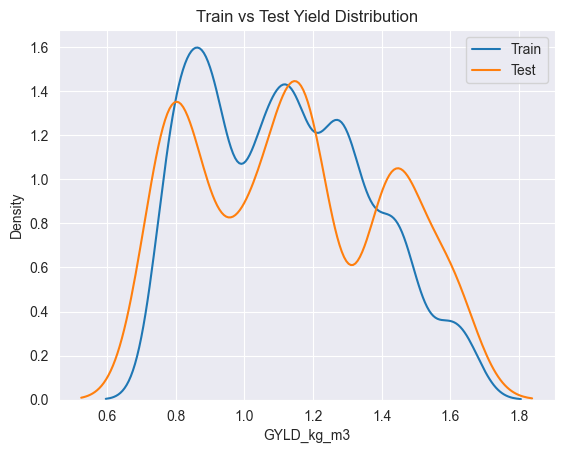

In [7]:
sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")


In [8]:
window_size = 30

def make_windows(dataframe):
    X_list, y_list = [], []
    for plot_id, group in dataframe.groupby('plot_id'):
        feature_matrix = group[features].values
        yield_value = group[output_variable].iloc[0]
        for i in range(len(feature_matrix) - window_size + 1):
            window = feature_matrix[i:i+window_size, :]
            X_list.append(window)
            y_list.append(yield_value)
    return np.array(X_list), np.array(y_list).reshape(-1, 1)



In [9]:
pad_value = -99

def make_progressive_windows(dataframe):
    X_list, y_list = [], []
    for plot_id, group in dataframe.groupby('plot_id'):
        feature_matrix = group[features].values.astype(np.float32)
        yield_value = group[output_variable].iloc[0].astype(np.float32)

        # Progressive prediction: from day 1 to full season
        for i in range(1, len(feature_matrix) + 1):  # from 1 day to full length
            window = feature_matrix[:i, :]           # NDVI from day 1 to day i
            assert window.shape[0] > 0
            # pad shorter sequences (for model input consistency)
            if len(window) < window_size:
                pad_len = window_size - len(window)
                pad = np.full((pad_len, feature_matrix.shape[1]), pad_value, dtype=np.float32)
                mask = np.concatenate([np.zeros(pad_len), np.ones(len(window))])
                window = np.vstack([pad, window])     # pad at the beginning
            else:
                window = window[-window_size:, :]     # use last window_size days
                mask = np.ones(window_size)
            window_with_mask = np.concatenate([window, mask.reshape(-1, 1)], axis=1)

            X_list.append(window)
            y_list.append(yield_value)

    X_array = np.array(X_list, dtype=np.float32)
    y_array = np.array(y_list, dtype=np.float32).reshape(-1, 1)

    return X_array, y_array

In [10]:
X_train_scaled, y_train_scaled = make_progressive_windows(train_df_scaled)

X_test_scaled, y_test_scaled = make_progressive_windows(test_df_scaled)

In [11]:
num_na_rows =np.isnan(X_train_scaled).any().sum()
print(f"X_train_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = np.isnan(y_train_scaled).any().sum()
print(f"y_train_scaled Rows with at least one NaN: {num_na_rows}")

X_train_scaled Rows with at least one NaN: 0
y_train_scaled Rows with at least one NaN: 0


In [12]:
class NDVIDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]



train_dataset = NDVIDataset(X_train_scaled, y_train_scaled)
test_dataset = NDVIDataset(X_test_scaled, y_test_scaled)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last timestep
        out = self.fc(out)
        return out


class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(
            input_size=input_size,   # number of features per time step
            hidden_size=hidden_size, # number of hidden units
            num_layers=num_layers,   # stacked GRU layers
            batch_first=True,        # (batch, seq, feature)
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)            # out: (batch, seq, hidden)
        out = out[:, -1, :]             # take last time step
        out = self.fc(out)              # predict yield
        return out


In [14]:

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# model = LSTMModel(input_size=len(features), hidden_size=8, num_layers=2, dropout=0.2).to(device)

# model = LSTMModel(input_size=len(features), hidden_size=16, num_layers=2, dropout=0.4).to(device)

# model = LSTMModel(input_size=len(features), hidden_size=16, num_layers=1).to(device)
# model = LSTMModel(input_size=len(features), hidden_size=32, num_layers=1).to(device)

# Not scaled data, window =30
# Train R²: 0.2719, Train MSE: 0.0455
# Test R²: 0.1809, Test MSE: 0.0452

# Scaled data, window =30
# Train R²: 0.8806, Train MSE: 0.0075
# Test R²: 0.7337, Test MSE: 0.0147

# model = LSTMModel(input_size=len(features), hidden_size=32, num_layers=2).to(device)
# Scaled data, window =30
# Train R²: 0.9349, Train MSE: 0.0041
# Test R²: 0.7948, Test MSE: 0.0113

# model = LSTMModel(input_size=len(features), hidden_size=64, num_layers=2).to(device)

model = GRUModel(input_size=len(features), hidden_size=8, num_layers=2, output_size=1, dropout=0.3).to(device)
# Train R²: 0.4864, Train MSE: 0.0295
# Test R²: 0.3013, Test MSE: 0.0526

# criterion = nn.SmoothL1Loss(beta=1) and with gradient clipping
# Train R²: 0.7017, Train MSE: 0.0171
# Test R²: 0.3247, Test MSE: 0.0508

In [15]:
best_train_loss  = float('inf')
patience = 20
counter = 0

# criterion = nn.MSELoss()
criterion = nn.SmoothL1Loss(beta=1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 500
train_losses =[]
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)
    train_losses.append(train_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.5f}")

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered.")
            break





Epoch [1/500] - Train Loss: 0.21554
Epoch [2/500] - Train Loss: 0.17964
Epoch [3/500] - Train Loss: 0.15967
Epoch [4/500] - Train Loss: 0.14960
Epoch [5/500] - Train Loss: 0.14424
Epoch [6/500] - Train Loss: 0.14090
Epoch [7/500] - Train Loss: 0.13872
Epoch [8/500] - Train Loss: 0.13633
Epoch [9/500] - Train Loss: 0.13422
Epoch [10/500] - Train Loss: 0.13310
Epoch [11/500] - Train Loss: 0.13263
Epoch [12/500] - Train Loss: 0.13063
Epoch [13/500] - Train Loss: 0.12964
Epoch [14/500] - Train Loss: 0.12831
Epoch [15/500] - Train Loss: 0.12615
Epoch [16/500] - Train Loss: 0.12503
Epoch [17/500] - Train Loss: 0.12313
Epoch [18/500] - Train Loss: 0.12206
Epoch [19/500] - Train Loss: 0.12281
Epoch [20/500] - Train Loss: 0.12024
Epoch [21/500] - Train Loss: 0.11835
Epoch [22/500] - Train Loss: 0.11766
Epoch [23/500] - Train Loss: 0.11725
Epoch [24/500] - Train Loss: 0.11674
Epoch [25/500] - Train Loss: 0.11593
Epoch [26/500] - Train Loss: 0.11419
Epoch [27/500] - Train Loss: 0.11468
Epoch [28/

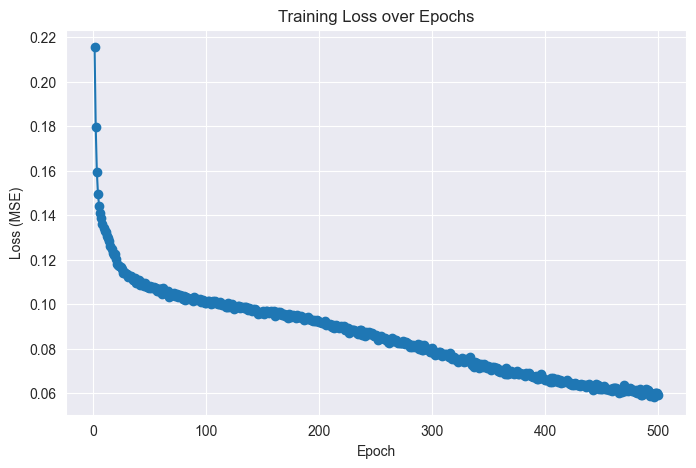

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, num_epochs+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

In [32]:
from sklearn.metrics import r2_score, mean_squared_error

def evaluate_model(model, dataloader, device):
    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_hat = model(X_batch)

            # Move to CPU and convert to numpy
            y_true.append(y_batch.cpu().numpy())
            y_pred.append(y_hat.cpu().numpy())

    # Stack all batches
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    y_true_orig = scaler_y.inverse_transform(y_true)
    y_pred_orig = scaler_y.inverse_transform(y_pred)
    r2 = r2_score(y_true_orig, y_pred_orig)
    mse = mean_squared_error(y_true_orig, y_pred_orig)

    bins = np.linspace(y_true_orig.min(), y_true_orig.max(), 5)
    digitized = np.digitize(y_true_orig.flatten(), bins)
    for b in np.unique(digitized):
        mask = digitized==b
        print(b, np.sqrt(((y_true_orig[mask]-y_pred_orig[mask])**2).mean()))


    plt.figure(figsize=(8,6))
    plt.scatter(y_true_orig, y_pred_orig, alpha=0.7)
    plt.plot([y_true_orig.min(), y_true_orig.max()], [y_true_orig.min(), y_true_orig.max()], 'r--')
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title("LSTM Predictions vs Actual")
    plt.show()

    return r2, mse

1 0.13223644
2 0.10727217
3 0.12228362
4 0.18790361
5 0.122477755


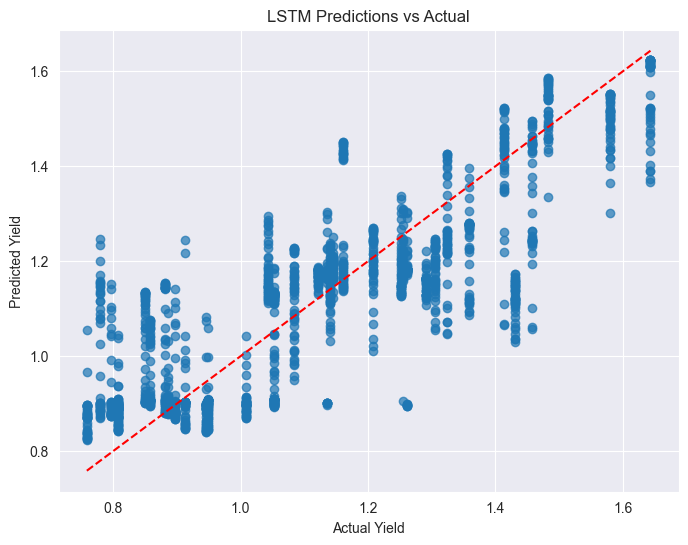

1 0.20614254
2 0.26005915
3 0.23644914
4 0.19591008
5 0.21307334


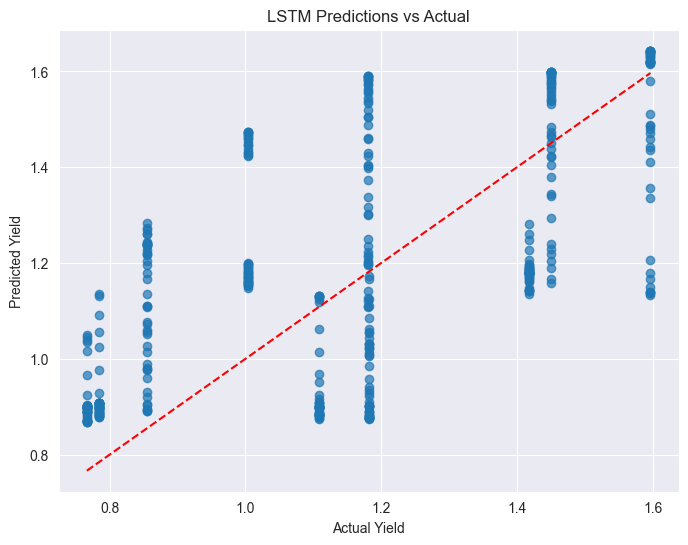

Train R²: 0.7017, Train MSE: 0.0171
Test R²: 0.3247, Test MSE: 0.0508


In [33]:

# Training metrics
r2_train, mse_train = evaluate_model(model, train_loader, device)
# Test metrics
r2_test, mse_test = evaluate_model(model, test_loader, device)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [34]:
# save model
torch.save(model.state_dict(), "models/gru_yield_model_3.pth")
torch.save(model, "models/gru_yield_model_full_3.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "scalers/scaler_X_3.save")
joblib.dump(scaler_y, "scalers/scaler_y_3.save")

['scalers/scaler_y_3.save']

Another way

In [ ]:
df_interp = df_linear_interpolated_and_smoothed.sort_values(['plot_id', 'date'])

# Pivot to have NDVI time series as columns (dates)
ndvi_wide = df_interp.pivot(index='plot_id', columns='date', values='ndvi_noir_rgb_method')
# Extract yield (same for all dates in a plot)
y = df_interp.groupby('plot_id')['GYLD_bu_ac'].first().values.reshape(-1, 1)

# Select the first 3 days of NDVI as input
X = ndvi_wide.values[:,:3]

y

In [ ]:
ndvi_wide

In [ ]:
print(y.shape)

In [ ]:
print(X.shape)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y = y.flatten()  # yields array (47,)
y_pred_baseline = np.full_like(y, y.mean(), dtype=float)
print("Baseline RMSE:", np.sqrt(mean_squared_error(y, y_pred_baseline)))
print("Baseline R2:", r2_score(y, y_pred_baseline))


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, BatchNormalization, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

df = df_linear_interpolated_and_smoothed.sort_values(['plot_id', 'date'])

ndvi_wide = df.pivot(index='plot_id', columns='date', values='ndvi_noir_rgb_method')
y = df.groupby('plot_id')['GYLD_bu_ac'].first()

# 2. Normalize NDVI per plot (shape-based scaling)
ndvi_norm = ndvi_wide.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1).fillna(0)

X = ndvi_norm.values[..., np.newaxis]  # shape (plots, timesteps, 1)
y = y.values

# 3. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale target (fit only on training)
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

# 5. Build a small, regularized LSTM
model = Sequential()
model.add(Input(shape=(X.shape[1], 1)))
model.add(Masking(mask_value=0.0))
model.add(LSTM(100, activation='relu', kernel_regularizer=l2(0.01)))
model.add(BatchNormalization())
model.add(Dropout(0.3))
model.add(Dense(1))
optimizer = Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse')

early_stopping = EarlyStopping(monitor='val_loss', patience=75, restore_best_weights=True)

# 6. Train

history = model.fit(
    X_train, y_train_scaled,
    validation_split=0.2,
    epochs=500,
    batch_size=8,
    verbose=0,
     callbacks=[early_stopping]
)

# 7. Evaluate
y_pred_scaled = model.predict(X_test)
y_pred = y_scaler.inverse_transform(y_pred_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"LSTM RMSE: {rmse:.2f}, R²: {r2:.3f}")

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)   # fit + transform
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))  # fit + transform

X_test_scaled = scaler_x.transform(X_test)         # only transform!
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))        # only transform!

In [ ]:

# Reshape X for LSTM: (samples, timesteps, features)
X_train_scaled = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_scaled = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

In [ ]:
X_train_scaled.shape

In [ ]:
X_train_scaled[:,:,0]

In [ ]:
X_test_scaled.shape

In [ ]:
X_test_scaled[:,:,0]

In [ ]:
print(f"Mean={y_train_scaled.mean():.2f}, Std={y_train_scaled.std():.2f}, Min={y_train_scaled.min()}, Max={y_train_scaled.max()}")
print(f"Mean={y_test_scaled.mean():.2f}, Std={y_test_scaled.std():.2f}, Min={y_test_scaled.min()}, Max={y_test_scaled.max()}")


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(32, activation='tanh', input_shape=(X_train_scaled.shape[1], 1)),
    Dense(16, activation='relu'),
    Dense(1)  # output = yield
])

model.compile(optimizer='adam', loss='mse')
model.summary()


In [ ]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    validation_data=(X_test_scaled, y_test_scaled),
    epochs=200,
    batch_size=8,
    verbose=1
)


In [ ]:
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test_scaled)


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("LSTM Predictions vs Actual")
plt.show()


In [ ]:
y_test_scaled.shape

In [ ]:
X_test_scaled